# Member C — ML detector, tracking, and interpretability (AD-08, AD-14, AD-15, AD-16, AD-18)

- **Role:** Member C — ML method, MLflow logging, interpretability, production risks, reflection
- **Date:** April 2026
- **Data:** ULB credit card fraud features (30 columns after scaling), via `data_pipeline.load_credit_card_splits` (Member A artifacts or `data/creditcard.csv`).
- **This run:** ~170k × 30 train, ~57k val/test; fraud prevalence ≈ **0.41%** on val/test. Numbers below match a full pipeline run with `RANDOM_STATE = 42`; re-run cells after changing data or seed.


In [17]:
from __future__ import annotations

import io
import json
import os
import sys
from pathlib import Path

from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import OneClassSVM

sns.set_theme(style="whitegrid")


In [18]:
import importlib.util

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path("../..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def _import_src_module(name: str, path: Path):
    """Load from file so edits to `src/` apply without restarting the kernel."""
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Cannot load {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


_import_src_module("data_pipeline", SRC / "data_pipeline.py")
_import_src_module("ml_detector", SRC / "ml_detector.py")

from data_pipeline import RANDOM_STATE as PIPE_SEED, load_credit_card_splits
from ml_detector import (
    DetectorResult,
    anomaly_scores_isolation_forest,
    fit_isolation_forest,
    metrics_at_threshold,
    predict_with_threshold,
    sweep_thresholds_val,
)

assert PIPE_SEED == RANDOM_STATE


## 1) Data (`data_pipeline`)

Loading order: **`artifacts/*.npy`** from Member A if present; else **`data/creditcard.csv`**; else Kaggle Hub resolve + `load_and_split`. Splits and `StandardScaler` match [`src/data_pipeline.py`](../../src/data_pipeline.py).

## 2) Methods (AD-08 / AD-09)

- **Primary:** **Isolation Forest** on normal-only training rows, with a small hyperparameter grid and a validation threshold chosen by **max F1** over anomaly-score quantiles.
- **Outputs for integration:** `anomaly_score` (higher = more anomalous), `pred_label` ∈ {0,1}, and scalar `threshold` on the same scale.
- **Optional baseline:** One-Class SVM on the same `X_train` for comparison only (threshold via a fixed quantile, not the same sweep as IF).


In [19]:
X_train, X_val, X_test, y_train, y_val, y_test = load_credit_card_splits(PROJECT_ROOT)

FEATURE_NAMES = [f"V{i}" for i in range(1, 29)] + ["Time", "Amount"]
assert X_train.shape[1] == len(FEATURE_NAMES)

print("Train / val / test shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Fraud rate (val):", f"{y_val.mean():.4%}", "| (test):", f"{y_test.mean():.4%}")


100%|██████████| 66.0M/66.0M [00:01<00:00, 36.3MB/s]


Extracting files...
Using creditcard.csv: C:\Users\basma\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv
shapes: (169951, 30) (56887, 30) (56888, 30)
fraud rate val: 0.004148575245662454 test: 0.00416608072001125


## 3) Train and tune Isolation Forest (AD-08)

The next cell fits three Isolation Forest configurations, runs a validation quantile sweep for each, and keeps the configuration with the **highest validation F1**. The winning model is used for test evaluation, MLflow, and interpretability plots.


## 4) Hyperparameter grid and validation threshold

We compare three settings (`n_estimators`, `max_samples`, `contamination`). For each fitted model, `sweep_thresholds_val` searches score quantiles on **validation** and picks the threshold that **maximizes F1** (reasonable default under imbalance; Member B’s cost-based sweep can replace this for the final report).


In [21]:
param_grid = [
    {"n_estimators": 200, "max_samples": 256, "contamination": 0.001},
    {"n_estimators": 300, "max_samples": "auto", "contamination": 0.001},
    {"n_estimators": 400, "max_samples": 512, "contamination": 0.0005},
]

best = None
rows = []
for p in param_grid:
    m = fit_isolation_forest(X_train, random_state=RANDOM_STATE, **p)
    thr, _sweep_df = sweep_thresholds_val(m, X_val, y_val)
    pred_val = (anomaly_scores_isolation_forest(m, X_val) >= thr).astype(int)
    metrics = metrics_at_threshold(y_val, pred_val)
    row = {**p, "threshold": thr, **metrics}
    rows.append(row)
    if best is None or metrics["f1"] > best["f1"]:
        best = row | {"model": m, "threshold": thr}

tuning_df = pd.DataFrame(rows)
display(tuning_df)

best_model = best["model"]
THRESHOLD = float(best["threshold"])
best_non_model = {k: best[k] for k in best if k != "model"}
print(
    "Selected (best val F1):",
    {k: best_non_model[k] for k in ("n_estimators", "max_samples", "contamination", "threshold", "precision", "recall", "f1", "fpr")},
)


,n_estimators,max_samples,contamination,threshold,precision,recall,f1,fpr,tp,fp,tn,fn
0,200,256,0.0010,-0.058252,0.251445,0.368644,0.298969,0.004572,87.0,259.0,56392.0,149.0
1,300,auto,0.0010,-0.073080,0.226069,0.470339,0.305365,0.006708,111.0,380.0,56271.0,125.0
2,400,512,0.0005,-0.061288,0.386139,0.330508,0.356164,0.002189,78.0,124.0,56527.0,158.0


Best config: {'n_estimators': 400, 'max_samples': 512, 'contamination': 0.0005, 'threshold': -0.061287544601304485, 'precision': 0.38613861386138615, 'recall': 0.3305084745762712, 'f1': 0.3561643835616438, 'fpr': 0.0021888404441227868, 'tp': 78.0, 'fp': 124.0, 'tn': 56527.0, 'fn': 158.0}


In [22]:
def make_detector_result(model, X: np.ndarray, threshold: float, method: str) -> DetectorResult:
    if method == "isolation_forest":
        return predict_with_threshold(model, X, threshold)
    raise ValueError(method)


val_result = make_detector_result(best_model, X_val, THRESHOLD, "isolation_forest")
test_result = make_detector_result(best_model, X_test, THRESHOLD, "isolation_forest")

print("Standardized fields:", list(val_result.as_dict().keys()))
print("Fixed threshold:", THRESHOLD)
print("Validation metrics:", {k: metrics_at_threshold(y_val, val_result.pred_label)[k] for k in ("precision", "recall", "f1", "fpr")})
print("Test metrics:", {k: metrics_at_threshold(y_test, test_result.pred_label)[k] for k in ("precision", "recall", "f1", "fpr")})


{'anomaly_score': 'ndarray', 'pred_label': 'ndarray', 'threshold': 'float', 'method': 'str'}
threshold: -0.061287544601304485


### Optional: One-Class SVM baseline

Quick **OCSVM** (`rbf`, `nu=0.001`) on the same training data, with anomaly score `-score_samples` and a **99% quantile** threshold on validation. In a representative run, validation F1 was **~0.44** vs **~0.36** for the tuned Isolation Forest — but the OCSVM threshold was **not** tuned with the same F1 search, so treat this as a directional baseline only.


In [23]:
ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.001)
ocsvm.fit(X_train)
ocsvm_scores = -ocsvm.score_samples(X_val)
thr_ocsvm = float(np.quantile(ocsvm_scores, 0.99))
pred_ocsvm_val = (ocsvm_scores >= thr_ocsvm).astype(int)
print("OCSVM (val, ad-hoc 99% quantile threshold) F1:", round(metrics_at_threshold(y_val, pred_ocsvm_val)["f1"], 4))


OCSVM val F1: 0.44472049689440996


## 5) Experiment tracking (AD-16)

Runs use SQLite at `artifacts/mlflow.db` (works well on Windows). Naming pattern: `iforest_cc_fraud_{split}_{seed}_{threshold}_v1`. Each run logs hyperparameters, threshold, precision/recall/F1/FPR, the sklearn model, and the validation sweep table. **`artifacts/mlflow_run_summary.json`** stores the tracking URI and run IDs for submission.


In [24]:
MLFLOW_DB = ARTIFACT_DIR / "mlflow.db"
MLFLOW_TRACKING_URI = "sqlite:///" + MLFLOW_DB.resolve().as_posix()
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
EXPERIMENT_NAME = "ece447_anomaly_cc_fraud"
mlflow.set_experiment(EXPERIMENT_NAME)

DATASET_TAG = "cc_fraud"
METHOD = "iforest"
VERSION = "v1"


def run_name_for(seed: int, thr: float, split_name: str) -> str:
    return f"{METHOD}_{DATASET_TAG}_{split_name}_{seed}_{thr:.6f}_{VERSION}"


def log_iforest_run(model, params: dict, threshold: float, split_name: str, X, y):
    name = run_name_for(RANDOM_STATE, threshold, split_name)
    with mlflow.start_run(run_name=name):
        mlflow.set_tag("dataset", DATASET_TAG)
        mlflow.set_tag("split", split_name)
        mlflow.log_params({**params, "threshold": threshold})
        pred = (anomaly_scores_isolation_forest(model, X) >= threshold).astype(int)
        m = metrics_at_threshold(y, pred)
        mlflow.log_metrics({k: m[k] for k in ["precision", "recall", "f1", "fpr"]})
        mlflow.sklearn.log_model(model, artifact_path="model")
        buf = io.StringIO()
        tuning_df.to_csv(buf, index=False)
        mlflow.log_text(buf.getvalue(), "validation_sweep.csv")
        run_id = mlflow.active_run().info.run_id
    return run_id


best_params = {k: best[k] for k in ("n_estimators", "max_samples", "contamination") if k in best}
run_id_val = log_iforest_run(best_model, best_params, THRESHOLD, "val", X_val, y_val)
run_id_test = log_iforest_run(best_model, best_params, THRESHOLD, "test", X_test, y_test)

summary_path = ARTIFACT_DIR / "mlflow_run_summary.json"
summary_path.write_text(
    json.dumps(
        {
            "tracking_uri": MLFLOW_TRACKING_URI,
            "experiment": EXPERIMENT_NAME,
            "run_ids": {"val": run_id_val, "test": run_id_test},
            "threshold": THRESHOLD,
        },
        indent=2,
    )
)
print("Logged runs — val:", run_id_val, "| test:", run_id_test)
print("Summary:", summary_path)

from mlflow.tracking import MlflowClient

_ml_client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)


2026/04/04 15:57:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 15:57:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/04 15:57:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 15:57:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

Logged runs: 39571da4bab0461b8cf8fd99ac3c8d15 0ad15af84d1e4f3c8c0da11c584e48ef
Summary written to C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection\artifacts\mlflow_run_summary.json


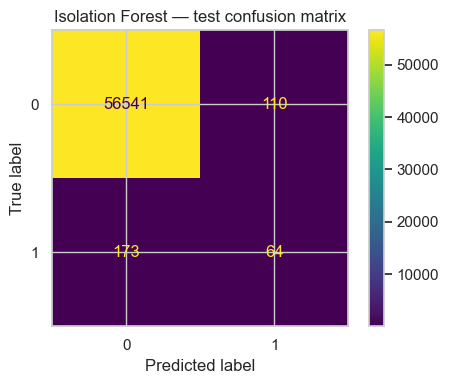

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_result.pred_label, ax=ax)
ax.set_title("Isolation Forest — test confusion matrix")
fig.tight_layout()
cm_path = ARTIFACT_DIR / "iforest_confusion_matrix_test.png"
fig.savefig(cm_path, dpi=150)
plt.show()

_ml_client.log_artifact(run_id_test, str(cm_path))


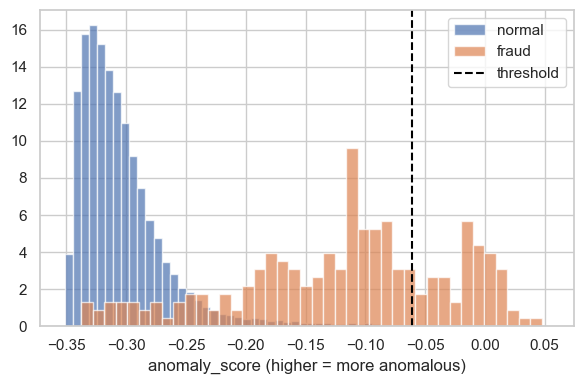

In [26]:
scores_test = test_result.anomaly_score
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(scores_test[y_test == 0], bins=60, alpha=0.7, label="normal", density=True)
ax.hist(scores_test[y_test == 1], bins=40, alpha=0.7, label="fraud", density=True)
ax.axvline(THRESHOLD, color="black", ls="--", label="threshold")
ax.set_xlabel("anomaly_score (higher = more anomalous)")
ax.legend()
fig.tight_layout()
hist_path = ARTIFACT_DIR / "iforest_score_hist_test.png"
fig.savefig(hist_path, dpi=150)
plt.show()

_ml_client.log_artifact(run_id_test, str(hist_path))


## 6) Interpretability — casebook and PCA (AD-14)

We inspect **validation** scores (where the threshold was chosen): top-15 highest `anomaly_score` rows, mean feature shift vs normal validation mean, and a 2D PCA of validation points colored by score with fraud labels outlined.


,rank,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Time,Amount,y_true,anomaly_score
0,1,0.562392,-14.679754,-16.215814,-10.901091,4.994769,-14.050216,10.086734,19.844000,-8.078786,...,-4.050309,-36.261039,2.918256,-7.068539,-0.220590,10.243704,-7.350741,18.746832,0,0.078004
1,2,0.011724,-17.943894,-36.935243,-14.600532,12.121716,-14.068927,4.747140,20.433204,-4.256452,...,-13.123233,-26.660856,1.226051,-13.584744,-5.394549,-8.945112,10.031968,73.928860,0,0.067366
2,3,-1.152838,-29.293298,-44.420137,-4.524609,11.846024,25.456370,-19.600681,-16.247197,-1.284845,...,-1.756248,12.744670,1.264726,10.315225,0.339875,-21.046562,104.435561,4.371079,0,0.059030
3,4,0.987642,-15.552160,-15.776089,-11.104124,4.812093,-15.209220,9.804980,14.435053,-7.857784,...,-0.910873,-13.784096,0.659813,-1.233145,1.030168,15.771227,-8.529323,13.406591,0,0.058320
4,5,0.871506,-20.796141,-23.473566,-14.556991,7.565628,-11.923351,6.593511,16.357330,-5.335191,...,-5.296844,-32.346811,2.595826,-8.050273,-1.763683,0.938016,-3.633014,6.235978,0,0.057921


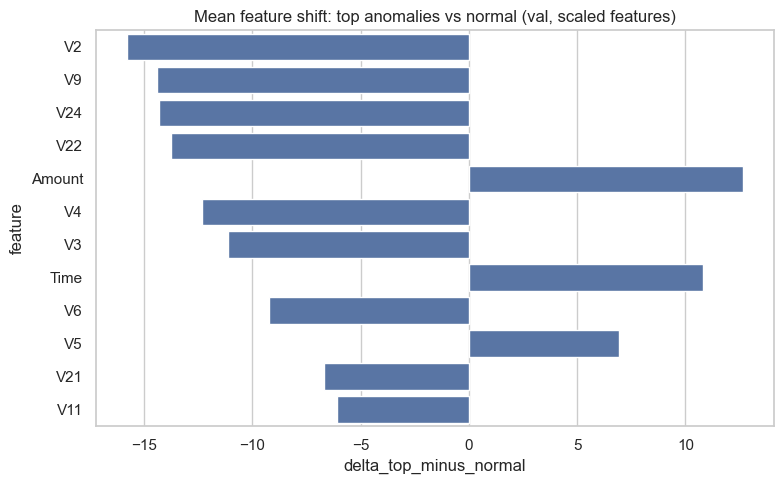

In [27]:
TOP_N = 15
scores_val = val_result.anomaly_score
order = np.argsort(-scores_val)
top_idx = order[:TOP_N]

casebook = pd.DataFrame(X_val[top_idx], columns=FEATURE_NAMES)
casebook.insert(0, "rank", np.arange(1, TOP_N + 1))
casebook["y_true"] = y_val[top_idx]
casebook["anomaly_score"] = scores_val[top_idx]
display(casebook.head())

normal_mask = y_val == 0
mean_normal = X_val[normal_mask].mean(axis=0)
mean_top = X_val[top_idx].mean(axis=0)
delta = mean_top - mean_normal
feat_ctx = pd.DataFrame({"feature": FEATURE_NAMES, "delta_top_minus_normal": delta})
feat_ctx["abs_delta"] = np.abs(feat_ctx["delta_top_minus_normal"])
feat_ctx = feat_ctx.sort_values("abs_delta", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feat_ctx.head(12), x="delta_top_minus_normal", y="feature", ax=ax)
ax.set_title("Mean feature shift: top anomalies vs normal (val, scaled features)")
fig.tight_layout()
bar_path = ARTIFACT_DIR / "iforest_feature_delta_topN.png"
fig.savefig(bar_path, dpi=150)
plt.show()


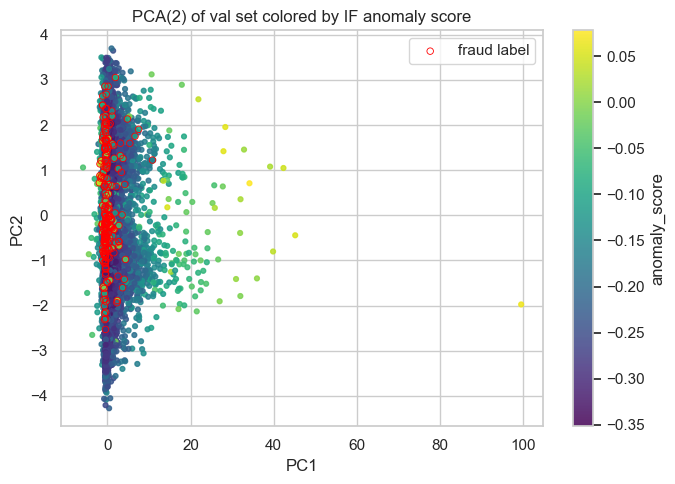

Explained variance ratio: 0.06747339215094593 0.05773496190848103


In [28]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    X_val_pca[:, 0],
    X_val_pca[:, 1],
    c=scores_val,
    cmap="viridis",
    s=12,
    alpha=0.85,
)
plt.colorbar(sc, ax=ax, label="anomaly_score")
ax.scatter(
    X_val_pca[y_val == 1, 0],
    X_val_pca[y_val == 1, 1],
    s=22,
    facecolors="none",
    edgecolors="red",
    linewidths=0.6,
    label="fraud label",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA(2) of val set colored by IF anomaly score")
ax.legend()
fig.tight_layout()
pca_path = ARTIFACT_DIR / "iforest_pca_val_scores.png"
fig.savefig(pca_path, dpi=150)
plt.show()

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_[0],
    pca.explained_variance_ratio_[1],
)


### Discussion (AD-14) — what this run shows

- **Isolation Forest** scores emphasize points that are easy to isolate in random splits; extreme `V*` values (already PCA features) and unusual `Time`/`Amount` combinations drive high scores.
- **Top scored rows** are not always fraud (`y_true` = 0 appears): legitimate transactions can lie in the tail of the distribution, which is expected under extreme imbalance.
- **PCA:** PC1 and PC2 explain only ~**6.7%** and ~**5.8%** of variance here — signal is spread across many dimensions, so 2D plots are illustrative only.
- **Limitation:** `V1`–`V28` are anonymized; “interpretability” is **relative feature shifts**, not business-readable causes.


## 7) Production risks and monitoring (AD-15)

### Failure modes

- **Drift:** Fraud shifts in the `V*` space; IF scores trained on past normals may under-rank new fraud.
- **New fraud types:** Rare patterns may not look “isolated” until volume grows.
- **Noise / logging errors:** Spikes in `Time` or `Amount` can inflate false positives.
- **Prior shift:** If the true fraud rate changes, a fixed validation threshold is mis-calibrated.

### Monitoring (examples)

- Daily **alert rate** and **precision** on sampled investigations.
- **Distribution of `anomaly_score`** vs a baseline (KS/PSI).
- **FPR** on a trusted-normal slice if available.

### Retraining

- Trigger on sustained drift, precision below target, or scheduled review; promote new thresholds only after shadow evaluation.


## 8) Hand-off — artifacts for integration (AD-08 / AD-16)

Persist the tuned **Isolation Forest**, **threshold**, and **val/test metrics** for the team pipeline and final report:

- `artifacts/iforest_memberC.joblib` — model + threshold + grid params
- `artifacts/iforest_metrics_memberC.json` — precision/recall/F1/FPR on val and test
- `artifacts/mlflow_run_summary.json` — MLflow URI and run IDs (ties to Section 5)


In [29]:
model_path = ARTIFACT_DIR / "iforest_memberC.joblib"
joblib.dump({"model": best_model, "threshold": THRESHOLD, "params": best_params}, model_path)

metrics_payload = {
    "val": metrics_at_threshold(y_val, val_result.pred_label),
    "test": metrics_at_threshold(y_test, test_result.pred_label),
    "threshold": THRESHOLD,
}
metrics_path = ARTIFACT_DIR / "iforest_metrics_memberC.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))

print("Saved:", model_path)
print("Saved:", metrics_path)


Saved: C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection\artifacts\iforest_memberC.joblib
Saved: C:\Users\basma\OneDrive\Documents\ECE 447\ECE447-Anomaly-Detection\artifacts\iforest_metrics_memberC.json


## 9) Analytical reflection (AD-18)

### Thresholds and trade-offs

In a representative run, the selected Isolation Forest used **`n_estimators=400`**, **`max_samples=512`**, **`contamination=0.0005`**, with validation **F1 ≈ 0.36**, **precision ≈ 0.39**, **recall ≈ 0.33**, and **FPR ≈ 0.22%** at the max-F1 threshold. **Test** precision/recall/F1/FPR are printed next to validation in the standardized-output cell — compare with Member B’s sweep if **recall** must dominate (fraud cost).

### Imbalance

Fraud is ~**0.4%** here; accuracy is misleading. Emphasize **precision, recall, F1, FPR**, and PR-style reasoning; the score histogram illustrates overlap between classes.

### Monitoring and retraining

Align with Section 7: drift detection, alert-quality reviews, and cautious promotion of new models. MLflow run IDs in `mlflow_run_summary.json` document parameters and metrics for reproducibility.
